# LangSight — WBF Ensemble Evaluation (YOLOv11n + Grounding DINO)

Capstone 29 | S1 Sains Data | Universitas Telkom

Gabungkan prediksi YOLO dan DINO pakai Weighted Box Fusion (WBF).
Bobot per kelas dihitung otomatis dari metrik evaluasi masing-masing model.

File input yang dibutuhkan di `/content/`:
- `langsight_best_pt.zip` (model YOLO)
- `gt_review.json`
- `eval_summary_yolo.json` (dari notebook 01)
- `eval_summary_dino.json` (dari notebook 02)

Output utama:
- `ensemble_weights.json` — dimuat oleh app.py saat startup
- `eval_summary_ensemble.json` — laporan evaluasi lengkap

Formula bobot:
  score(model, cls) = F1(model, cls) x AP@50(model, cls)
  w_yolo(cls) = score_yolo^2 / (score_yolo^2 + score_dino^2)
  w_dino(cls) = 1 - w_yolo(cls)
  Kelas DINO-only (sharpener, clip, notebook): w_dino = 1.0


In [1]:
!pip install ultralytics roboflow transformers torch torchvision \
             opencv-python pillow numpy pandas \
             matplotlib seaborn scikit-learn tqdm -q

import os, re, json, time, warnings, inspect, math, gc
import random
from pathlib import Path
from collections import defaultdict, Counter

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image
from tqdm import tqdm
from sklearn.metrics import precision_recall_curve, average_precision_score
import torch
import yaml

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=0.95)
plt.rcParams['figure.dpi'] = 110
random.seed(42); np.random.seed(42)

print(f'PyTorch : {torch.__version__}')
print(f'CUDA    : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
print('Import selesai.')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 79.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 110.6 MB/s eta 0:00:00
PyTorch : 2.10.0+cu128
CUDA    : True
GPU     : Tesla T4
Import selesai.


In [ ]:
# ── Konstanta (SYNCED dengan app.py v7.0 dan kedua eval notebook) ────────────
ROBOFLOW_API_KEY = 'L3OgcMAfQualsYoVK5K5'
BASE      = Path('/content')
DATA_DIR  = BASE / 'eval_datasets'
OUT_DIR   = BASE / 'eval_results_ensemble'
MODEL_ZIP = BASE / 'langsight_best_pt.zip'
DATA_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

GDINO_MODEL_ID   = 'IDEA-Research/grounding-dino-base'
TARGET_9_CLASSES = ['pen', 'pencil', 'eraser', 'sharpener', 'correction_tape', 'stapler', 'clip', 'bottle', 'notebook']

CLASS_PROMPTS = {
    "pen": (
        "ballpoint pen . ink pen . writing pen . gel pen . "
        "long thin plastic pen . black office pen . "
        "retractable writing pen . slim writing instrument . "
        "plastic ballpoint writing tool . handheld pen object ."
    ),

    "pencil": (
        "graphite pencil . wooden pencil . lead pencil . "
        "drafting pencil . long thin pencil . yellow pencil . "
        "hexagonal wooden pencil . sharpened writing pencil . "
        "school pencil . traditional graphite writing tool ."
    ),

    "eraser": (
        "rubber eraser block . white eraser . pencil eraser . "
        "small rectangular eraser . soft rubber erasing tool . "
        "stationery eraser . correction eraser block . "
        "compact rubber eraser . handheld erasing object . "
        "school eraser tool ."
    ),

    "sharpener": (
        "pencil sharpener . handheld sharpener . "
        "small plastic sharpener . cylindrical pencil sharpener . "
        "manual pencil sharpening tool . desktop sharpener . "
        "compact sharpening device . stationery sharpener . "
        "small blade pencil sharpener . handheld stationery tool ."
    ),

    "correction_tape": (
        "correction tape . white out tape . correction roller . "
        "white correction roller . small white correction dispenser . "
        "rectangular correction tape dispenser . tipex roller . "
        "stationery correction device . handheld correction tool . "
        "white correction strip applicator ."
    ),

    "stapler": (
        "office stapler . paper stapler . manual stapler . "
        "desktop stapler . metal office stapling tool . "
        "black office stapler . handheld stapling device . "
        "paper fastening tool . standard desk stapler . "
        "compact office stapler machine ."
    ),

    "clip": (
        "paper clip . binder clip . metal paperclip . "
        "small metal paper clip . tiny silver wire clip . "
        "flat metallic paperclip . thin metal document fastener . "
        "office document clip . stationery fastening clip . "
        "small silver office clip ."
    ),

    "bottle": (
        "water bottle . drink bottle . beverage container . "
        "plastic water bottle . transparent drink bottle . "
        "cylindrical bottle . reusable water container . "
        "liquid container bottle . portable drinking bottle . "
        "plastic beverage vessel ."
    ),

    "notebook": (
        "spiral notebook . exercise book . notepad . "
        "lined notebook . paper notebook . "
        "spiral bound writing notebook . school notebook . "
        "paper writing book . stationery notebook object . "
        "bound paper notebook ."
    ),
}

YOLO_TO_TARGET = {'pen': 'pen', 'pencil': 'pencil', 'eraser': 'eraser', 'stapler': 'stapler', 'correction_tape': 'correction_tape', 'bottle': 'bottle'}
YOLO_EVAL_CLASSES  = list(YOLO_TO_TARGET.values())
DINO_ONLY_CLASSES  = ['sharpener', 'clip', 'notebook']

DEFAULT_BOX_THR  = 0.35
DEFAULT_TEXT_THR = 0.25
IOU_THRESHOLD    = 0.5
WBF_IOU_THR      = 0.5
YOLO_CONF_THR    = 0.25
MIN_GT           = 5

ADAPTIVE_IOU      = {'pen': 0.3, 'pencil': 0.3, 'clip': 0.3, 'correction_tape': 0.35, 'stapler': 0.4}
PER_CLASS_BOX_THR = {'pencil': 0.22, 'clip': 0.22, 'correction_tape': 0.25, 'sharpener': 0.25, 'stapler': 0.25}
CLASS_MAP         = {'pen': 'pen', 'ballpen': 'pen', 'ballpoint': 'pen', 'ball point': 'pen', 'ballpoint pen': 'pen', 'gel pen': 'pen', 'signpen': 'pen', 'sign pen': 'pen', 'fineliner': 'pen', 'ink pen': 'pen', 'rollerball pen': 'pen', 'felt tip pen': 'pen', 'writing pen': 'pen', 'drawing pen': 'pen', 'pencil': 'pencil', 'mechanical pencil': 'pencil', 'graphite pencil': 'pencil', 'wooden pencil': 'pencil', 'hb pencil': 'pencil', '2b pencil': 'pencil', 'lead pencil': 'pencil', 'drafting pencil': 'pencil', 'eraser': 'eraser', 'pencil eraser': 'eraser', 'white eraser': 'eraser', 'eraser block': 'eraser', 'rubber eraser': 'eraser', 'rubber': 'eraser', 'sharpener': 'sharpener', 'sharpner': 'sharpener', 'pencil sharpener': 'sharpener', 'handheld sharpener': 'sharpener', 'correction tape': 'correction_tape', 'correctiontape': 'correction_tape', 'correction pen': 'correction_tape', 'tipex': 'correction_tape', 'tipp-ex': 'correction_tape', 'white-out': 'correction_tape', 'whiteout': 'correction_tape', 'liquid paper': 'correction_tape', 'correction-tape': 'correction_tape', 'white out tape': 'correction_tape', 'correction roller': 'correction_tape', 'tipex tape roller': 'correction_tape', 'stapler': 'stapler', 'paper stapler': 'stapler', 'office stapler': 'stapler', 'manual stapler': 'stapler', 'objects': 'stapler', 'paper clip': 'clip', 'paperclip': 'clip', 'binder clip': 'clip', 'clip': 'clip', 'bulldog clip': 'clip', 'foldback clip': 'clip', 'metal clip': 'clip', 'document clip': 'clip', 'metal paperclip': 'clip', 'bottle': 'bottle', 'water bottle': 'bottle', 'waterbottle': 'bottle', 'tumbler': 'bottle', 'drink bottle': 'bottle', 'flask': 'bottle', 'bottle_detect': 'bottle', 'beverage container': 'bottle', 'plastic bottle': 'bottle', 'drink': 'bottle', 'notebook': 'notebook', 'exercise book': 'notebook', 'notepad': 'notebook', 'spiral notebook': 'notebook', 'writing notebook': 'notebook', 'composition book': 'notebook', 'lined notebook': 'notebook', 'school notebook': 'notebook', 'memo pad': 'notebook'}

print(f'9 kelas target  : {TARGET_9_CLASSES}')
print(f'YOLO+DINO       : {YOLO_EVAL_CLASSES}')
print(f'DINO-only       : {DINO_ONLY_CLASSES}')
print(f'WBF IoU         : {WBF_IOU_THR}')
print(f'YOLO conf       : {YOLO_CONF_THR}')
print(f'DINO box thr    : {DEFAULT_BOX_THR}')


9 kelas target  : ['pen', 'pencil', 'eraser', 'sharpener', 'correction_tape', 'stapler', 'clip', 'bottle', 'notebook']
YOLO+DINO       : ['pen', 'pencil', 'eraser', 'stapler', 'correction_tape', 'bottle']
DINO-only       : ['sharpener', 'clip', 'notebook']
WBF IoU         : 0.5
YOLO conf       : 0.25
DINO box thr    : 0.35


In [3]:
# Verifikasi semua file input
required = {
    'langsight_best_pt.zip' : MODEL_ZIP,
    'gt_review.json'        : BASE/'gt_review.json',
    'eval_summary_yolo.json': BASE/'eval_summary_yolo.json',
    'eval_summary_dino.json': BASE/'eval_summary_dino.json',
}
all_ok = True
for fname,fpath in required.items():
    if fpath.exists():
        print(f'  OK   {fname} ({fpath.stat().st_size/1024:.1f} KB)')
    else:
        alts = list(BASE.glob('gt_review*.json')) if 'gt_review' in fname else []
        if alts:
            print(f'  OK   {alts[0].name}  (alternatif untuk {fname})')
        else:
            print(f'  MISS {fname} — upload ke /content/ dulu')
            all_ok = False
if all_ok: print('\nSemua file tersedia.')
else:       print('\nBeberapa file hilang. Upload lalu run cell ini lagi.')


  OK   langsight_best_pt.zip (5318.0 KB)
  OK   gt_review.json (40.0 KB)
  OK   eval_summary_yolo.json (3.9 KB)
  OK   eval_summary_dino.json (4.6 KB)

Semua file tersedia.


In [4]:
# Load eval summary JSON dari kedua notebook
with open(BASE/'eval_summary_yolo.json') as f:
    yolo_summary = json.load(f)
with open(BASE/'eval_summary_dino.json') as f:
    dino_summary = json.load(f)

print('Macro metrics dari evaluasi terpisah:')
ym=yolo_summary.get('macro_metrics',{})
dm=dino_summary.get('macro_metrics',{})
print(f'  YOLO  F1={ym.get("f1",0):.4f}  mAP@50={ym.get("mAP_50",0):.4f}  Recall={ym.get("recall",0):.4f}')
print(f'  DINO  F1={dm.get("f1",0):.4f}  mAP@50={dm.get("mAP_50",0):.4f}  Recall={dm.get("recall",0):.4f}')


Macro metrics dari evaluasi terpisah:
  YOLO  F1=0.5746  mAP@50=0.8319  Recall=0.5219
  DINO  F1=0.5272  mAP@50=0.7065  Recall=0.8543


In [5]:
# Hitung bobot WBF per kelas
def compute_class_weights(yolo_per, dino_per, target_classes,
                          yolo_eval_classes, dino_only_classes,
                          alpha=2.0, floor=0.10, min_score=0.01):
    weights = {}
    for cls in target_classes:
        # DINO-only: YOLO tidak punya kelas ini
        if cls in dino_only_classes:
            d = dino_per.get(cls, {})
            weights[cls] = {
                'w_yolo': 0.0, 'w_dino': 1.0, 'reason': 'dino_only',
                'yolo_f1': None, 'yolo_ap50': None,
                'dino_f1': d.get('f1_score', d.get('f1', 0.0)),
                'dino_ap50': d.get('ap_50', 0.0),
            }
            continue

        y = yolo_per.get(cls, {})
        d = dino_per.get(cls, {})
        y_f1   = y.get('f1_score', y.get('f1', 0.0))
        y_ap50 = y.get('ap_50', 0.0)
        d_f1   = d.get('f1_score', d.get('f1', 0.0))
        d_ap50 = d.get('ap_50', 0.0)
        y_has  = y.get('has_gt', False) and (y_f1>0 or y_ap50>0)
        d_has  = d.get('has_gt', False) and (d_f1>0 or d_ap50>0)

        if y_has and not d_has:
            reason='yolo_only'; w_y=1.0; w_d=0.0
        elif d_has and not y_has:
            reason='dino_only_measured'; w_y=0.0; w_d=1.0
        elif not y_has and not d_has:
            reason='no_data_default50'; w_y=0.5; w_d=0.5
        else:
            y_score=max(y_f1*y_ap50, min_score)
            d_score=max(d_f1*d_ap50, min_score)
            y_pow=y_score**alpha; d_pow=d_score**alpha
            w_y=y_pow/(y_pow+d_pow); w_d=1-w_y
            if w_y<floor: w_y=floor; w_d=1-floor
            elif w_d<floor: w_d=floor; w_y=1-floor
            reason='computed'

        weights[cls]={
            'w_yolo': round(w_y,4), 'w_dino': round(w_d,4), 'reason': reason,
            'yolo_f1': y_f1, 'yolo_ap50': y_ap50,
            'dino_f1': d_f1, 'dino_ap50': d_ap50,
        }
    return weights

CLASS_WEIGHTS = compute_class_weights(
    yolo_summary.get('per_class_metrics', {}),
    dino_summary.get('per_class_metrics', {}),
    TARGET_9_CLASSES, YOLO_EVAL_CLASSES, DINO_ONLY_CLASSES,
    alpha=2.0, floor=0.10,
)

print('Bobot WBF per kelas (alpha=2.0, floor=0.10):')
print(f'  {"Kelas":<22} {"YOLO_F1":>8} {"YOLO_AP":>8} {"DINO_F1":>8} {"DINO_AP":>8} {"w_YOLO":>8} {"w_DINO":>8}  reason')
for cls in TARGET_9_CLASSES:
    w=CLASS_WEIGHTS[cls]
    yf  = f'{w["yolo_f1"]:.3f}' if w['yolo_f1'] is not None else '-'
    yap = f'{w["yolo_ap50"]:.3f}' if w['yolo_ap50'] is not None else '-'
    print(f'  {cls:<22} {yf:>8} {yap:>8} {w["dino_f1"]:>8.3f} {w["dino_ap50"]:>8.3f} '
          f'{w["w_yolo"]:>8.3f} {w["w_dino"]:>8.3f}  {w["reason"]}')


Bobot WBF per kelas (alpha=2.0, floor=0.10):
  Kelas                   YOLO_F1  YOLO_AP  DINO_F1  DINO_AP   w_YOLO   w_DINO  reason
  pen                       0.600    0.761    0.545    0.688    0.597    0.403  computed
  pencil                    0.447    0.754    0.417    0.366    0.830    0.170  computed
  eraser                    0.381    0.592    0.513    0.582    0.363    0.637  computed
  sharpener                     -        -    0.592    0.823    0.000    1.000  dino_only
  correction_tape           1.000    1.000    0.476    0.967    0.825    0.175  computed
  stapler                   0.412    0.976    0.480    0.674    0.607    0.393  computed
  clip                          -        -    0.526    0.838    0.000    1.000  dino_only
  bottle                    0.608    0.908    0.584    0.803    0.581    0.419  computed
  notebook                      -        -    0.611    0.617    0.000    1.000  dino_only


Disimpan: /content/eval_results_ensemble/ensemble_weights.json


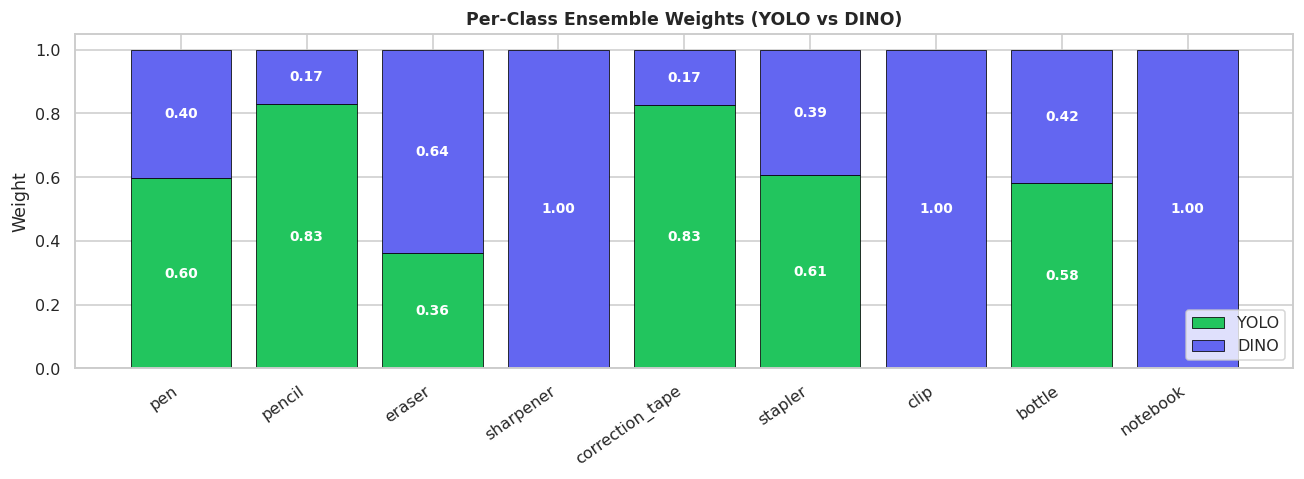

In [6]:
# Simpan ensemble_weights.json (dimuat oleh app.py)
weights_payload = {
    'meta': {
        'description'     : 'Per-class WBF weights from YOLO and DINO F1*AP@50',
        'formula'         : 'w = score^alpha / sum(score^alpha), score = F1 * AP@50',
        'alpha'           : 2.0,
        'floor'           : 0.10,
        'yolo_conf'       : YOLO_CONF_THR,
        'dino_box_thr'    : DEFAULT_BOX_THR,
        'dino_text_thr'   : DEFAULT_TEXT_THR,
        'wbf_iou'         : WBF_IOU_THR,
        'target_classes'  : TARGET_9_CLASSES,
        'yolo_eval_classes': YOLO_EVAL_CLASSES,
        'dino_only_classes': DINO_ONLY_CLASSES,
        'class_prompts'   : CLASS_PROMPTS,
        'per_class_box_thr': PER_CLASS_BOX_THR,
        'adaptive_iou'    : ADAPTIVE_IOU,
    },
    'weights': CLASS_WEIGHTS,
}

with open(OUT_DIR/'ensemble_weights.json','w') as f:
    json.dump(weights_payload,f,indent=2)
print(f'Disimpan: {OUT_DIR}/ensemble_weights.json')

# Visualisasi bobot stacked bar
fig,ax=plt.subplots(figsize=(12,4.5))
x=np.arange(len(TARGET_9_CLASSES))
wy=[CLASS_WEIGHTS[c]['w_yolo'] for c in TARGET_9_CLASSES]
wd=[CLASS_WEIGHTS[c]['w_dino'] for c in TARGET_9_CLASSES]
ax.bar(x,wy,label='YOLO',color='#22c55e',edgecolor='black',linewidth=0.5)
ax.bar(x,wd,bottom=wy,label='DINO',color='#6366f1',edgecolor='black',linewidth=0.5)
for i,cls in enumerate(TARGET_9_CLASSES):
    if wy[i]>0.08: ax.text(i,wy[i]/2,f'{wy[i]:.2f}',ha='center',va='center',
                            fontsize=9,fontweight='bold',color='white')
    if wd[i]>0.08: ax.text(i,wy[i]+wd[i]/2,f'{wd[i]:.2f}',ha='center',va='center',
                            fontsize=9,fontweight='bold',color='white')
ax.set_xticks(x); ax.set_xticklabels(TARGET_9_CLASSES,rotation=35,ha='right')
ax.set_ylabel('Weight'); ax.set_ylim(0,1.05)
ax.set_title('Per-Class Ensemble Weights (YOLO vs DINO)',fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(str(OUT_DIR/'ensemble_weights.png'),dpi=130,bbox_inches='tight')
plt.show()


In [7]:
# Load YOLO
from ultralytics import YOLO

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
print('Loading YOLOv11n...')
ckpt = torch.load(str(MODEL_ZIP), map_location='cpu', weights_only=False)
model_raw = ckpt['model'].float().to(DEVICE).eval()
tmp_pt = '/content/_yolo_tmp.pt'
torch.save({'model':model_raw,'names':model_raw.names}, tmp_pt)
yolo_model = YOLO(tmp_pt); yolo_model.to(DEVICE)
_ = yolo_model.predict(np.zeros((640,640,3),dtype=np.uint8),verbose=False,conf=0.01)
print(f'  YOLO native: {yolo_model.names}')
print('  Warmup OK.')


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Device: cuda
Loading YOLOv11n...
  YOLO native: {0: 'pen', 1: 'pencil', 2: 'eraser', 3: 'stapler', 4: 'correction_tape', 5: 'tissue', 6: 'bottle', 7: 'scissor'}
  Warmup OK.


In [8]:
# Load Grounding DINO
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection

DTYPE = torch.float32
print(f'Loading {GDINO_MODEL_ID}...')
processor   = AutoProcessor.from_pretrained(GDINO_MODEL_ID)
gdino_model = AutoModelForZeroShotObjectDetection.from_pretrained(
    GDINO_MODEL_ID, low_cpu_mem_usage=True,
).to(DEVICE).eval()
_pp_sig     = inspect.signature(processor.post_process_grounded_object_detection)
USE_NEW_API = 'box_threshold' not in _pp_sig.parameters
print(f'  API: {"new" if USE_NEW_API else "old"}')

def _gdino_raw(img_bgr, prompt, box_thr, text_thr):
    img_pil  = Image.fromarray(cv2.cvtColor(img_bgr,cv2.COLOR_BGR2RGB))
    inputs   = processor(images=img_pil,text=prompt,return_tensors='pt').to(DEVICE)
    input_ids = inputs['input_ids']
    with torch.inference_mode():
        with torch.autocast(device_type='cuda' if 'cuda' in DEVICE else 'cpu'):
            outputs = gdino_model(**inputs)
    kw = {'threshold':box_thr} if USE_NEW_API else \
         {'box_threshold':box_thr,'text_threshold':text_thr}
    results = processor.post_process_grounded_object_detection(
        outputs, input_ids, target_sizes=[img_pil.size[::-1]], **kw,
    )
    preds=[]
    if results and results[0].get('boxes') is not None:
        for score,label,box in zip(
            results[0]['scores'],results[0]['labels'],results[0]['boxes']
        ):
            x1,y1,x2,y2=[int(v) for v in box.tolist()]
            preds.append({'label':str(label),'score':float(score),'bbox':[x1,y1,x2,y2]})
    return preds

_ = _gdino_raw(np.zeros((480,640,3),dtype=np.uint8),'pen .',0.01,0.01)
print('  Warmup OK.')
if torch.cuda.is_available():
    free,total=torch.cuda.mem_get_info(0)
    print(f'VRAM: {free/1e9:.1f}/{total/1e9:.1f} GB free')
print('Kedua model siap.')


Loading IDEA-Research/grounding-dino-base...


preprocessor_config.json:   0%|          | 0.00/457 [00:00<?, ?B/s]

The image processor of type `GroundingDinoImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/933M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/1206 [00:00<?, ?it/s]

  API: new
  Warmup OK.
VRAM: 12.4/15.6 GB free
Kedua model siap.


In [9]:
# Fungsi WBF dan evaluasi

def iou_box(a,b):
    ax1,ay1,ax2,ay2=a; bx1,by1,bx2,by2=b
    ix1=max(ax1,bx1); iy1=max(ay1,by1)
    ix2=min(ax2,bx2); iy2=min(ay2,by2)
    inter=max(0,ix2-ix1)*max(0,iy2-iy1)
    if not inter: return 0.0
    union=(ax2-ax1)*(ay2-ay1)+(bx2-bx1)*(by2-by1)-inter
    return inter/union if union>0 else 0.0

def norm_to_pixel(cx,cy,bw,bh,W,H):
    x1=int((cx-bw/2)*W); y1=int((cy-bh/2)*H)
    x2=int((cx+bw/2)*W); y2=int((cy+bh/2)*H)
    return [max(0,x1),max(0,y1),min(W,x2),min(H,y2)]

def load_image_bgr(img_path):
    img=cv2.imread(str(img_path))
    if img is not None: return img
    try:
        pil=Image.open(str(img_path)).convert('RGB')
        return cv2.cvtColor(np.array(pil),cv2.COLOR_RGB2BGR)
    except: return None

def yolo_predict(img_bgr, conf=YOLO_CONF_THR):
    out=defaultdict(list)
    results=yolo_model.predict(img_bgr,verbose=False,conf=conf,device=DEVICE)
    if results and results[0].boxes is not None:
        for i in range(len(results[0].boxes)):
            cls_id=int(results[0].boxes.cls[i].item())
            tgt=YOLO_TO_TARGET.get(yolo_model.names[cls_id])
            if not tgt: continue
            score=float(results[0].boxes.conf[i].item())
            xyxy=[int(v) for v in results[0].boxes.xyxy[i].tolist()]
            out[tgt].append((score,xyxy))
    return out

def dino_predict(img_bgr, cls, box_thr=None, text_thr=DEFAULT_TEXT_THR):
    if cls not in CLASS_PROMPTS: return []
    bt=box_thr if box_thr is not None else PER_CLASS_BOX_THR.get(cls,DEFAULT_BOX_THR)
    try:
        preds=_gdino_raw(img_bgr,CLASS_PROMPTS[cls],bt,text_thr)
        return [(p['score'],p['bbox']) for p in preds]
    except: return []

def wbf_fuse(yolo_dets, dino_dets, w_yolo, w_dino, iou_thr=WBF_IOU_THR):
    """Fuse box dari 2 sumber. Output: [{score,bbox,source,contributors}]."""
    items=[]
    for s,b in yolo_dets: items.append({'score':s,'bbox':b,'src':'yolo','w':w_yolo})
    for s,b in dino_dets: items.append({'score':s,'bbox':b,'src':'dino','w':w_dino})
    if not items: return []
    items.sort(key=lambda x:-x['score'])
    used=[False]*len(items); fused=[]
    for i in range(len(items)):
        if used[i]: continue
        cluster=[items[i]]; used[i]=True
        for j in range(i+1,len(items)):
            if used[j]: continue
            if iou_box(items[i]['bbox'],items[j]['bbox'])>=iou_thr:
                cluster.append(items[j]); used[j]=True
        srcs=set(c['src'] for c in cluster)
        ws=[c['w']*c['score'] for c in cluster]
        sw=sum(ws)
        if sw==0: continue
        fx1=sum(c['bbox'][0]*w for c,w in zip(cluster,ws))/sw
        fy1=sum(c['bbox'][1]*w for c,w in zip(cluster,ws))/sw
        fx2=sum(c['bbox'][2]*w for c,w in zip(cluster,ws))/sw
        fy2=sum(c['bbox'][3]*w for c,w in zip(cluster,ws))/sw
        sps={s:max((c['score'] for c in cluster if c['src']==s),default=0) for s in srcs}
        if len(srcs)==1:
            src=list(srcs)[0]; escore=sps[src]
        else:
            escore=w_yolo*sps.get('yolo',0)+w_dino*sps.get('dino',0); src='ensemble'
        fused.append({
            'score':round(min(1.0,escore),4),
            'bbox':[int(fx1),int(fy1),int(fx2),int(fy2)],
            'source':src,'contributors':sorted(list(srcs)),
        })
    return sorted(fused,key=lambda x:-x['score'])

def ensemble_predict(img_bgr, cls):
    """Predict satu kelas pakai WBF ensemble."""
    w=CLASS_WEIGHTS.get(cls,{'w_yolo':0.5,'w_dino':0.5})
    w_y=w['w_yolo']; w_d=w['w_dino']
    if cls in DINO_ONLY_CLASSES:
        preds=dino_predict(img_bgr,cls)
        return [{'score':s,'bbox':b,'source':'dino_only','contributors':['dino']}
                for s,b in preds]
    yolo_all=yolo_predict(img_bgr)
    yolo_dets=yolo_all.get(cls,[])
    dino_dets=dino_predict(img_bgr,cls)
    return wbf_fuse(yolo_dets,dino_dets,w_y,w_d)

def compute_metrics(agg):
    out={}
    for cls,r in agg.items():
        tp,fp,fn=r['tp'],r['fp'],r['fn']
        p=tp/(tp+fp) if tp+fp else 0.0
        rc=tp/(tp+fn) if tp+fn else 0.0
        f1=2*p*rc/(p+rc) if p+rc else 0.0
        out[cls]={'precision':round(p,4),'recall':round(rc,4),'f1':round(f1,4),
                  'tp':tp,'fp':fp,'fn':fn,'n_gt':r.get('n_gt',tp+fn)}
    return out

print('Fungsi WBF dan evaluasi siap.')


Fungsi WBF dan evaluasi siap.


In [10]:
# Download + parse GT
from roboflow import Roboflow
rf = Roboflow(api_key=ROBOFLOW_API_KEY)

EVAL_DATASETS = [{'name': 'ds_stationary', 'workspace': 'national-university-fast', 'project': 'stationary-items-dataset', 'version': 8, 'desc': 'pen, pencil, eraser, ruler, notebook'}, {'name': 'ds_stationery', 'workspace': '65704680', 'project': 'stationery-clhrb', 'version': 6, 'desc': 'pen, pencil, eraser, scissors'}, {'name': 'ds_correction_tape', 'workspace': 'han-sy', 'project': 'correction-tape', 'version': 3, 'desc': 'correction_tape'}, {'name': 'ds_stapler', 'workspace': 'kavya-5k61i', 'project': 'stapler-yrkcg', 'version': 1, 'desc': 'stapler'}, {'name': 'ds_clip', 'workspace': 'multimedia', 'project': 'clip-xs5dn', 'version': 1, 'desc': 'clip'}, {'name': 'ds_bottle', 'workspace': 'aaaa-lg0ki', 'project': 'bottle-detection-ak5ic', 'version': 1, 'desc': 'bottle'}]
DS_PRIORITY   = ['ds_stationary', 'ds_stationery', 'ds_correction_tape', 'ds_stapler', 'ds_clip', 'ds_bottle']

downloaded={}
for ds in EVAL_DATASETS:
    dst=DATA_DIR/ds['name']
    if dst.exists() and any(dst.rglob('*.jpg')):
        print(f"  {ds['name']}: sudah ada, skip"); downloaded[ds['name']]=dst; continue
    try:
        rf.workspace(ds['workspace']).project(ds['project']) \
          .version(ds['version']).download('yolov11',location=str(dst))
        downloaded[ds['name']]=dst; print(f"  {ds['name']}: OK")
    except Exception as e: print(f"  {ds['name']}: GAGAL {e}")

def parse_gt(ds_root):
    yaml_path=next(ds_root.rglob('data.yaml'),None)
    if not yaml_path: return []
    with open(yaml_path) as f: cfg=yaml.safe_load(f)
    classes=cfg.get('names',[])
    if isinstance(classes,dict): classes=[classes[k] for k in sorted(classes.keys())]
    img_dir=None
    for s in ['val','valid','test','train']:
        d=next((x for x in ds_root.rglob(f'{s}/images') if x.is_dir()),None)
        if d: img_dir=d; break
    if not img_dir: return []
    lbl_dir=img_dir.parent/'labels'
    if not lbl_dir.exists(): return []
    records=[]
    for lp in sorted(lbl_dir.glob('*.txt')):
        imgs=[p for p in img_dir.glob(lp.stem+'.*')
              if p.suffix.lower() in ('.jpg','.jpeg','.png','.bmp')]
        if not imgs: continue
        boxes=[]
        with open(lp) as f:
            for line in f:
                parts=line.strip().split()
                if len(parts)<5: continue
                try: oid=int(float(parts[0]))
                except ValueError: continue
                if oid>=len(classes): continue
                raw=re.sub(r'\s+',' ',classes[oid].lower().strip())
                raw2=raw.split(' - ')[0].split(' v')[0].strip()
                gt_cls=CLASS_MAP.get(raw) or CLASS_MAP.get(raw2)
                if not gt_cls and raw=='objects' and 'stapler' in str(ds_root).lower(): gt_cls='stapler'
                if not gt_cls or gt_cls not in TARGET_9_CLASSES: continue
                try: cx,cy,bw,bh=map(float,parts[1:5])
                except ValueError: continue
                if not (0<bw<=1 and 0<bh<=1) or bw*bh<0.0005: continue
                boxes.append({'class':gt_cls,'bbox_norm':[cx,cy,bw,bh]})
        if boxes: records.append({'img_path':imgs[0],'ds_name':ds_root.name,'boxes':boxes})
    return records

all_records=[]; seen=set()
for ds_name in DS_PRIORITY:
    if ds_name in downloaded:
        for rec in parse_gt(downloaded[ds_name]):
            if rec['img_path'] in seen: continue
            seen.add(rec['img_path']); all_records.append(rec)

REVIEW_FILE=sorted(BASE.glob('gt_review*.json'))[0]
with open(REVIEW_FILE) as f: review_status=json.load(f)
def _key(rec): return str(rec['img_path'].relative_to(DATA_DIR))
before=len(all_records)
all_records=[r for r in all_records if review_status.get(_key(r))=='keep']

gt_cls_count=Counter(b['class'] for r in all_records for b in r['boxes'])
EVAL_CLS_FINAL=[c for c in gt_cls_count if gt_cls_count[c]>=MIN_GT]
print(f'Filter: {before} → {len(all_records)} gambar')
print(f'Kelas: {EVAL_CLS_FINAL}')


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /content/eval_datasets/ds_stationary in yolov11:: 100%|██████████| 2336/2336 [00:00<00:00, 6316.24it/s]

  ds_stationary: OK
loading Roboflow workspace...


loading Roboflow project...



Extracting Dataset Version Zip to /content/eval_datasets/ds_stationery in yolov11:: 100%|██████████| 438/438 [00:00<00:00, 8803.24it/s]

...


Extracting Dataset Version Zip to /content/eval_datasets/ds_clip in yolov11:: 100%|██████████| 105/105 [00:00<00:00, 9123.15it/s]

  ds_clip: OK
loading Roboflow workspace...


loading Roboflow project...



Extracting Dataset Version Zip to /content/eval_datasets/ds_bottle in yolov11:: 100%|██████████| 2486/2486 [00:00<00:00, 7729.86it/s]


  ds_bottle: OK
Filter: 389 → 148 gambar
Kelas: ['pen', 'eraser', 'notebook', 'pencil', 'sharpener', 'correction_tape', 'stapler', 'clip', 'bottle']


In [11]:
# Evaluasi ensemble
eval_records=all_records
print(f'Gambar: {len(eval_records)}')

agg=defaultdict(lambda:{'tp':0,'fp':0,'fn':0,'n_gt':0,'scores':[]})
errors=[]; t0=time.time()

for rec in tqdm(eval_records,desc='Ensemble eval',ncols=80):
    try:
        img=load_image_bgr(rec['img_path'])
        if img is None: continue
        H,W=img.shape[:2]
        for b in rec['boxes']:
            cls=b['class']
            if cls not in CLASS_PROMPTS: continue
            gts_px=[norm_to_pixel(*bb['bbox_norm'],W,H) for bb in rec['boxes'] if bb['class']==cls]
            if not gts_px: continue
            preds=ensemble_predict(img,cls)
            preds.sort(key=lambda x:-x['score'])
            tp=fp=0; scores=[]; matched=set()
            for p in preds:
                scores.append(p['score']); best_iou=0.0; best_i=-1
                for i,gt in enumerate(gts_px):
                    if i in matched: continue
                    iou=iou_box(p['bbox'],gt)
                    if iou>best_iou: best_iou=iou; best_i=i
                if best_iou>=ADAPTIVE_IOU.get(cls,IOU_THRESHOLD) and best_i>=0:
                    tp+=1; matched.add(best_i)
                else: fp+=1
            fn=len(gts_px)-tp
            agg[cls]['tp']+=tp; agg[cls]['fp']+=fp; agg[cls]['fn']+=fn
            agg[cls]['n_gt']+=len(gts_px); agg[cls]['scores'].extend(scores)
    except Exception as e: errors.append(str(e))

elapsed=time.time()-t0
print(f'\nSelesai: {elapsed/60:.1f} menit ({elapsed/max(1,len(eval_records)):.2f} s/img)')
if errors: print(f'Errors: {len(errors)}')

metrics=compute_metrics({c:r for c,r in agg.items() if c in EVAL_CLS_FINAL})
rows=[]
for cls in sorted(metrics,key=lambda x:-metrics[x]['recall']):
    m=metrics[cls]
    rows.append({'Kelas':cls,'GT':m['n_gt'],'TP':m['tp'],'FP':m['fp'],
                 'FN':m['fn'],'Precision':m['precision'],'Recall':m['recall'],'F1':m['f1']})
df_ens=pd.DataFrame(rows)
macro_p =df_ens['Precision'].mean() if len(df_ens) else 0.0
macro_r =df_ens['Recall'].mean() if len(df_ens) else 0.0
macro_f1=df_ens['F1'].mean() if len(df_ens) else 0.0

print(f'\nEnsemble evaluation:')
print(df_ens.to_string(index=False))
print()
print(f'  Macro Precision : {macro_p:.4f}')
print(f'  Macro Recall    : {macro_r:.4f}')
print(f'  Macro F1        : {macro_f1:.4f}')
df_ens.to_csv(OUT_DIR/'ensemble_eval_main.csv',index=False)


Gambar: 148


Ensemble eval: 100%|██████████████████████████| 148/148 [01:46<00:00,  1.39it/s]


Selesai: 1.8 menit (0.72 s/img)

Ensemble evaluation:
          Kelas  GT  TP  FP  FN  Precision  Recall     F1
correction_tape   5   5   1   0     0.8333  1.0000 0.9091
         pencil 426 417 119   9     0.7780  0.9789 0.8669
           clip  17  16  25   1     0.3902  0.9412 0.5517
        stapler  51  45   5   6     0.9000  0.8824 0.8911
       notebook  32  28  29   4     0.4912  0.8750 0.6292
         eraser  36  29  20   7     0.5918  0.8056 0.6824
            pen  48  38  12  10     0.7600  0.7917 0.7755
         bottle 164 119  43  45     0.7346  0.7256 0.7301
      sharpener  32  23  23   9     0.5000  0.7188 0.5897

  Macro Precision : 0.6643
  Macro Recall    : 0.8577
  Macro F1        : 0.7362


Perbandingan F1 per kelas:
          Kelas  YOLO_F1  DINO_F1  ENS_F1
            pen   0.6000   0.5455  0.7755
         pencil   0.4474   0.4167  0.8669
         eraser   0.3810   0.5135  0.6824
      sharpener   0.0000   0.5915  0.5897
correction_tape   1.0000   0.4762  0.9091
        stapler   0.4118   0.4800  0.8911
           clip   0.0000   0.5263  0.5517
         bottle   0.6076   0.5839  0.7301
       notebook   0.0000   0.6111  0.6292

Macro F1:  YOLO=0.5746  DINO=0.5272  Ensemble=0.7362
Macro R :  YOLO=0.5219  DINO=0.8543  Ensemble=0.8577


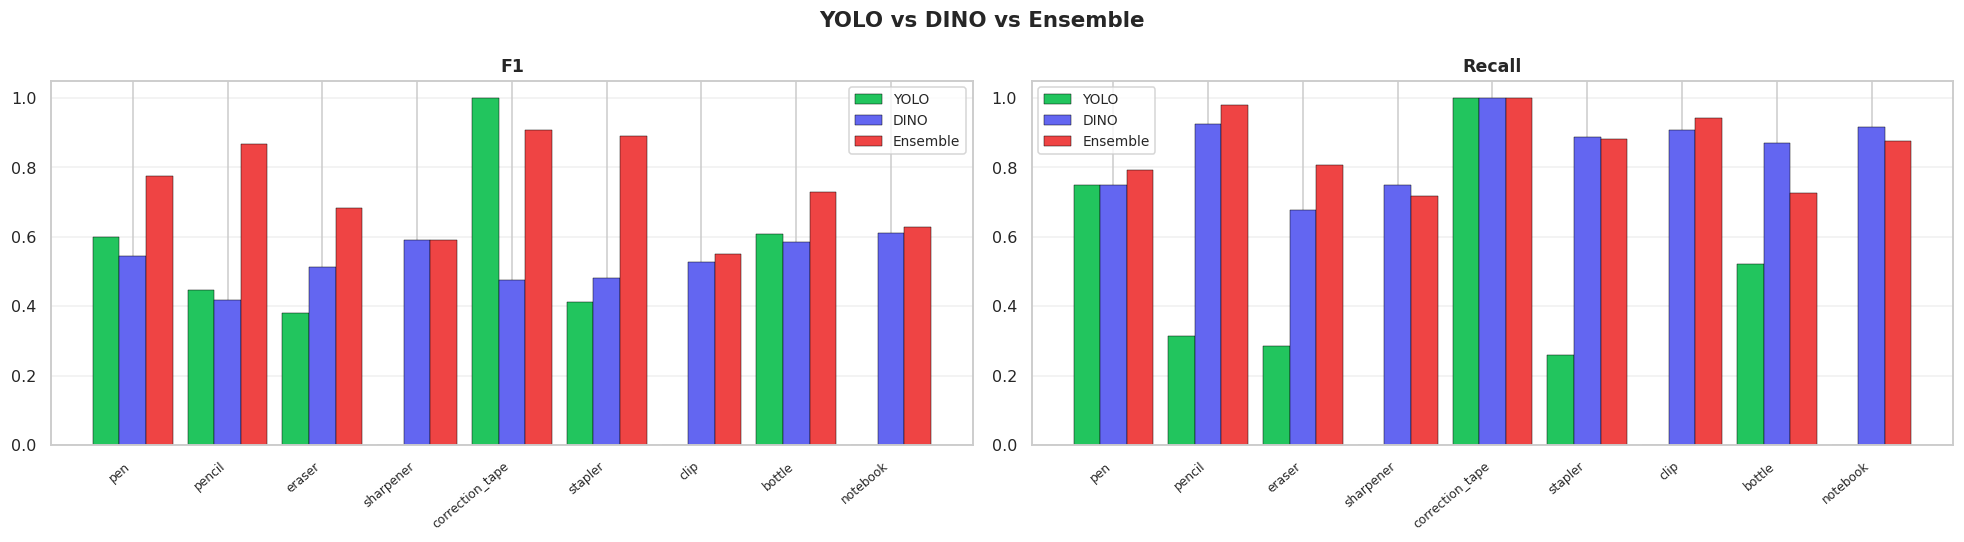

In [12]:
# Perbandingan YOLO vs DINO vs Ensemble
ym=yolo_summary.get('macro_metrics',{}); dm=dino_summary.get('macro_metrics',{})
comparison=[]
for cls in TARGET_9_CLASSES:
    y=yolo_summary.get('per_class_metrics',{}).get(cls,{})
    d=dino_summary.get('per_class_metrics',{}).get(cls,{})
    e=metrics.get(cls,{})
    comparison.append({
        'Kelas':cls,
        'YOLO_F1':y.get('f1_score',0),'DINO_F1':d.get('f1_score',0),'ENS_F1':e.get('f1',0),
        'YOLO_R':y.get('recall',0),   'DINO_R':d.get('recall',0),   'ENS_R':e.get('recall',0),
    })
df_cmp=pd.DataFrame(comparison)
print('Perbandingan F1 per kelas:')
print(df_cmp[['Kelas','YOLO_F1','DINO_F1','ENS_F1']].to_string(index=False))
print()
print(f'Macro F1:  YOLO={ym.get("f1",0):.4f}  DINO={dm.get("f1",0):.4f}  Ensemble={macro_f1:.4f}')
print(f'Macro R :  YOLO={ym.get("recall",0):.4f}  DINO={dm.get("recall",0):.4f}  Ensemble={macro_r:.4f}')

x=np.arange(len(TARGET_9_CLASSES)); w=0.28
fig,axes=plt.subplots(1,2,figsize=(18,5))
for ax,(m1,m2,m3,lbl) in zip(axes,[
    ([df_cmp.iloc[i]['YOLO_F1'] for i in range(len(df_cmp))],
     [df_cmp.iloc[i]['DINO_F1'] for i in range(len(df_cmp))],
     [df_cmp.iloc[i]['ENS_F1'] for i in range(len(df_cmp))], 'F1'),
    ([df_cmp.iloc[i]['YOLO_R'] for i in range(len(df_cmp))],
     [df_cmp.iloc[i]['DINO_R'] for i in range(len(df_cmp))],
     [df_cmp.iloc[i]['ENS_R'] for i in range(len(df_cmp))], 'Recall'),
]):
    ax.bar(x-w,m1,w,label='YOLO',color='#22c55e',edgecolor='black',linewidth=0.3)
    ax.bar(x,  m2,w,label='DINO',color='#6366f1',edgecolor='black',linewidth=0.3)
    ax.bar(x+w,m3,w,label='Ensemble',color='#ef4444',edgecolor='black',linewidth=0.3)
    ax.set_xticks(x); ax.set_xticklabels(TARGET_9_CLASSES,rotation=40,ha='right',fontsize=8)
    ax.set_title(lbl,fontweight='bold'); ax.set_ylim(0,1.05); ax.legend(fontsize=9)
    ax.grid(True,alpha=0.3,axis='y')
plt.suptitle('YOLO vs DINO vs Ensemble',fontsize=14,fontweight='bold')
plt.tight_layout()
plt.savefig(str(OUT_DIR/'ensemble_comparison.png'),dpi=130,bbox_inches='tight')
plt.show()


PR ensemble: 100%|██████████████████| 148/148 [01:11<00:00,  2.08it/s]


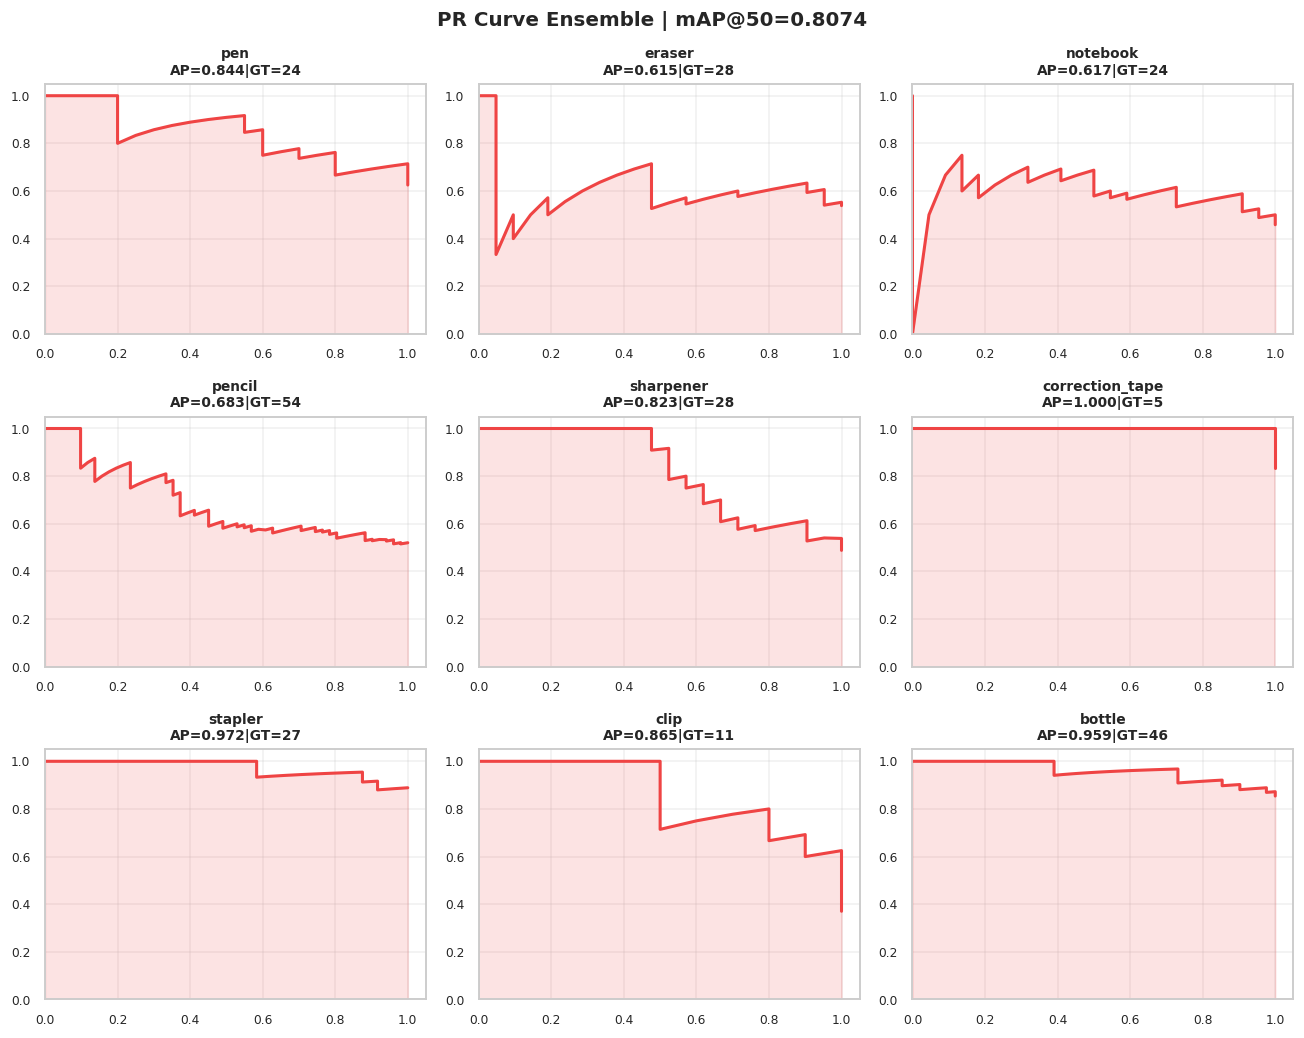

mAP Ensemble:
  mAP@50 : 0.8074  vs  YOLO=0.8319  DINO=0.7065
  mAP@30 : 0.8278
  mAP@75 : 0.6345


In [13]:
# PR Curves Ensemble
cls_scores=defaultdict(list); cls_n_gt=defaultdict(int)
for rec in tqdm(eval_records,desc='PR ensemble',ncols=70):
    try:
        img=load_image_bgr(rec['img_path'])
        if img is None: continue
        H,W=img.shape[:2]
        gt_per_cls=defaultdict(list)
        for b in rec['boxes']:
            gt_per_cls[b['class']].append(norm_to_pixel(*b['bbox_norm'],W,H))
            cls_n_gt[b['class']]+=1
        for cls,gts in gt_per_cls.items():
            preds=ensemble_predict(img,cls); preds.sort(key=lambda x:-x['score'])
            matched=set()
            for p in preds:
                best_iou=0.0; best_i=-1
                for i,gt in enumerate(gts):
                    if i in matched: continue
                    iou=iou_box(p['bbox'],gt)
                    if iou>best_iou: best_iou=iou; best_i=i
                if best_i>=0 and best_iou>=ADAPTIVE_IOU.get(cls,IOU_THRESHOLD): matched.add(best_i)
                cls_scores[cls].append((p['score'],best_iou))
    except: pass

cls_with_data=[c for c in EVAL_CLS_FINAL if cls_scores.get(c)]
ap_scores={}; ap_multi_iou={}
if cls_with_data:
    ncols=3; nrows=max(1,math.ceil(len(cls_with_data)/ncols))
    fig,axes=plt.subplots(nrows,ncols,figsize=(ncols*4,nrows*3.2))
    axes=np.array(axes).flatten() if hasattr(axes,'flatten') else np.array([axes])
    for i,cls in enumerate(cls_with_data):
        data=cls_scores[cls]; n_gt=cls_n_gt.get(cls,0)
        scores=np.array([d[0] for d in data]); ious=np.array([d[1] for d in data])
        labels=(ious>=ADAPTIVE_IOU.get(cls,IOU_THRESHOLD)).astype(int)
        aps_at={}
        for iou_t in [0.30,0.50,0.75]:
            lbl=(ious>=iou_t).astype(int)
            aps_at[iou_t]=float(average_precision_score(lbl,scores)) if lbl.sum()>0 else 0.0
        if labels.sum()==0:
            axes[i].set_title(f'{cls}\nAP=0|GT={n_gt}',fontsize=9,color='red')
            ap_scores[cls]=0.0; ap_multi_iou[cls]=aps_at
        else:
            try:
                pr,rc,_=precision_recall_curve(labels,scores)
                ap=float(average_precision_score(labels,scores))
                ap_scores[cls]=round(ap,4); ap_multi_iou[cls]=aps_at
                axes[i].plot(rc,pr,color='#ef4444',lw=2)
                axes[i].fill_between(rc,pr,alpha=0.15,color='#ef4444')
                axes[i].set_title(f'{cls}\nAP={ap:.3f}|GT={n_gt}',fontsize=9,fontweight='bold')
                axes[i].set_xlim(0,1.05); axes[i].set_ylim(0,1.05)
                axes[i].tick_params(labelsize=8); axes[i].grid(True,alpha=0.3)
            except: ap_scores[cls]=0.0
    for j in range(len(cls_with_data),len(axes)): axes[j].set_visible(False)
    mAP_50_val=sum(v.get(0.50,0) for v in ap_multi_iou.values())/max(1,len(ap_multi_iou))
    plt.suptitle(f'PR Curve Ensemble | mAP@50={mAP_50_val:.4f}',fontsize=13,fontweight='bold')
    plt.tight_layout()
    plt.savefig(str(OUT_DIR/'ensemble_pr_curves.png'),dpi=120,bbox_inches='tight')
    plt.show()

mAP=float(np.mean(list(ap_scores.values()))) if ap_scores else 0.0
mAP_30=float(np.mean([v.get(0.30,0) for v in ap_multi_iou.values()])) if ap_multi_iou else 0.0
mAP_50=float(np.mean([v.get(0.50,0) for v in ap_multi_iou.values()])) if ap_multi_iou else 0.0
mAP_75=float(np.mean([v.get(0.75,0) for v in ap_multi_iou.values()])) if ap_multi_iou else 0.0
print(f'mAP Ensemble:')
print(f'  mAP@50 : {mAP_50:.4f}  vs  YOLO={yolo_summary.get("overall_map_50",0):.4f}  DINO={dino_summary.get("overall_map_50",0):.4f}')
print(f'  mAP@30 : {mAP_30:.4f}')
print(f'  mAP@75 : {mAP_75:.4f}')
gc.collect(); torch.cuda.empty_cache()


In [14]:
# Export eval_summary_ensemble.json + update ensemble_weights.json dengan hasil eval
per_class_metrics={}
for cls in TARGET_9_CLASSES:
    if cls in metrics:
        m=metrics[cls]; ap=ap_scores.get(cls,0.0); aps=ap_multi_iou.get(cls,{})
        per_class_metrics[cls]={
            'precision':m['precision'],'recall':m['recall'],'f1_score':m['f1'],
            'ap':round(ap,4),'ap_50':round(aps.get(0.50,0),4),
            'ap_75':round(aps.get(0.75,0),4),'ap_30':round(aps.get(0.30,0),4),
            'true_positives':m['tp'],'false_positives':m['fp'],'false_negatives':m['fn'],
            'n_gt':m['n_gt'],'has_gt':True,'weights':CLASS_WEIGHTS.get(cls,{}),
        }
    else:
        per_class_metrics[cls]={
            'precision':0.0,'recall':0.0,'f1_score':0.0,'ap':0.0,
            'ap_50':0.0,'ap_75':0.0,'ap_30':0.0,
            'true_positives':0,'false_positives':0,'false_negatives':0,
            'n_gt':0,'has_gt':False,'weights':CLASS_WEIGHTS.get(cls,{}),
        }

ym=yolo_summary.get('macro_metrics',{}); dm=dino_summary.get('macro_metrics',{})
ens_summary={
    'model_name'    : 'ensemble_yolov11n_grounding_dino_base',
    'strategy'      : 'Weighted Box Fusion (WBF)',
    'weight_formula': {'score':'F1*AP@50','weight':'score^2/sum(score^2)','alpha':2.0,'floor':0.10},
    'config': {
        'yolo_conf':YOLO_CONF_THR,'dino_box_thr':DEFAULT_BOX_THR,
        'dino_text_thr':DEFAULT_TEXT_THR,'iou_threshold':IOU_THRESHOLD,
        'wbf_iou':WBF_IOU_THR,'adaptive_iou':ADAPTIVE_IOU,
        'per_class_box_thr':PER_CLASS_BOX_THR,'n_eval_images':len(eval_records),
    },
    'target_classes':TARGET_9_CLASSES,'yolo_eval_classes':YOLO_EVAL_CLASSES,
    'dino_only_classes':DINO_ONLY_CLASSES,'class_weights':CLASS_WEIGHTS,
    'class_prompts':CLASS_PROMPTS,
    'overall_map':round(mAP,4),'overall_map_50':round(mAP_50,4),
    'overall_map_75':round(mAP_75,4),'overall_map_30':round(mAP_30,4),
    'overall_precision':round(macro_p,4),'overall_recall':round(macro_r,4),'overall_f1':round(macro_f1,4),
    'macro_metrics':{
        'precision':round(macro_p,4),'recall':round(macro_r,4),'f1':round(macro_f1,4),
        'mAP_30':round(mAP_30,4),'mAP_50':round(mAP_50,4),'mAP_75':round(mAP_75,4),
        'mAP_adaptive':round(mAP,4),
    },
    'comparison_vs_single':{
        'yolo_f1':ym.get('f1',0),'yolo_mAP50':yolo_summary.get('overall_map_50',0),
        'dino_f1':dm.get('f1',0),'dino_mAP50':dino_summary.get('overall_map_50',0),
        'ensemble_f1':round(macro_f1,4),'ensemble_mAP50':round(mAP_50,4),
        'f1_delta_vs_best':round(macro_f1-max(ym.get('f1',0),dm.get('f1',0)),4),
        'mAP50_delta_vs_best':round(mAP_50-max(yolo_summary.get('overall_map_50',0),
                                               dino_summary.get('overall_map_50',0)),4),
    },
    'per_class_metrics':per_class_metrics,
}

with open(OUT_DIR/'eval_summary_ensemble.json','w') as f: json.dump(ens_summary,f,indent=2)
# Update ensemble_weights.json dengan eval results
with open(OUT_DIR/'ensemble_weights.json','w') as f:
    json.dump(weights_payload,f,indent=2)

print(f'Disimpan: eval_summary_ensemble.json  ({(OUT_DIR/"eval_summary_ensemble.json").stat().st_size/1024:.1f} KB)')
print(f'Disimpan: ensemble_weights.json  ({(OUT_DIR/"ensemble_weights.json").stat().st_size/1024:.1f} KB)')
print()
print(f'  {"Kelas":<22} {"Prec":>8} {"Recall":>8} {"F1":>8} {"AP@50":>8}')
for cls in TARGET_9_CLASSES:
    m=per_class_metrics[cls]
    if m['has_gt']:
        print(f'  {cls:<22} {m["precision"]:>8.4f} {m["recall"]:>8.4f} {m["f1_score"]:>8.4f} {m["ap_50"]:>8.4f}')
    else:
        print(f'  {cls:<22} (tidak ada GT)')


Disimpan: eval_summary_ensemble.json  (8.7 KB)
Disimpan: ensemble_weights.json  (3.4 KB)

  Kelas                      Prec   Recall       F1    AP@50
  pen                      0.7600   0.7917   0.7755   0.8441
  pencil                   0.7780   0.9789   0.8669   0.5981
  eraser                   0.5918   0.8056   0.6824   0.6152
  sharpener                0.5000   0.7188   0.5897   0.8227
  correction_tape          0.8333   1.0000   0.9091   1.0000
  stapler                  0.9000   0.8824   0.8911   0.9716
  clip                     0.3902   0.9412   0.5517   0.8383
  bottle                   0.7346   0.7256   0.7301   0.9592
  notebook                 0.4912   0.8750   0.6292   0.6172


In [15]:
# Download
print('File yang dihasilkan:')
for p in sorted(OUT_DIR.glob('*')):
    print(f'  {p.name:<45} ({p.stat().st_size/1024:.1f} KB)')

from google.colab import files as colab_files
print('\nDownload file utama (untuk app.py):')
for fname in ['ensemble_weights.json','eval_summary_ensemble.json']:
    try:
        colab_files.download(str(OUT_DIR/fname)); print(f'  OK: {fname}')
    except Exception as e: print(f'  Error {fname}: {e}')

print('\nDownload file pendukung:')
for fname in ['ensemble_eval_main.csv','ensemble_weights.png',
              'ensemble_comparison.png','ensemble_pr_curves.png']:
    fp=OUT_DIR/fname
    if fp.exists():
        try: colab_files.download(str(fp)); print(f'  OK: {fname}')
        except: pass
print('\nSelesai. ensemble_weights.json siap untuk app.py.')


File yang dihasilkan:
  ensemble_comparison.png                       (47.9 KB)
  ensemble_eval_main.csv                        (0.4 KB)
  ensemble_pr_curves.png                        (88.8 KB)
  ensemble_weights.json                         (3.4 KB)
  ensemble_weights.png                          (60.0 KB)
  eval_summary_ensemble.json                    (8.7 KB)

Download file utama (untuk app.py):


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  OK: ensemble_weights.json


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  OK: ensemble_comparison.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  OK: ensemble_pr_curves.png

Selesai. ensemble_weights.json siap untuk app.py.
